<a href="https://colab.research.google.com/github/tamaravera14/PROCESOS-ESTOCASTICOS/blob/main/Caminata_Aleatoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# Caminatas Aleatorias

---

*Bazaldua Vera Tamara Alheli*

---

Las caminatas aleatorias constituyen modelos matemáticos de naturaleza
estocástica que describen la evolución de una trayectoria formada por
una sucesión de pasos realizados al azar. Generalmente se representan
sobre una cuadrícula, una red o una recta numérica.

En este tipo de proceso, cada desplazamiento ocurre de manera
independiente respecto a los anteriores, y tanto su dirección como
su magnitud se determinan mediante un mecanismo probabilístico.
De esta forma, la posición final del objeto refleja la acumulación
de movimientos aleatorios que lo separan progresivamente de su
punto de partida.

Se define:

$X_0 = 0$ y para $t \ge 1$:

$X_t = \sum_{i=1}^{t} S_i$

donde las variables aleatorias $\{S_i\}$ son independientes e idénticamente
distribuidas (i.i.d.) tales que:

$
S_i =
\begin{cases}
+1 & \text{con probabilidad } p, \\
-1 & \text{con probabilidad } q,
\end{cases}
$

con $p + q = 1.$

Cada $S_i$ representa el desplazamiento en el paso $i$.

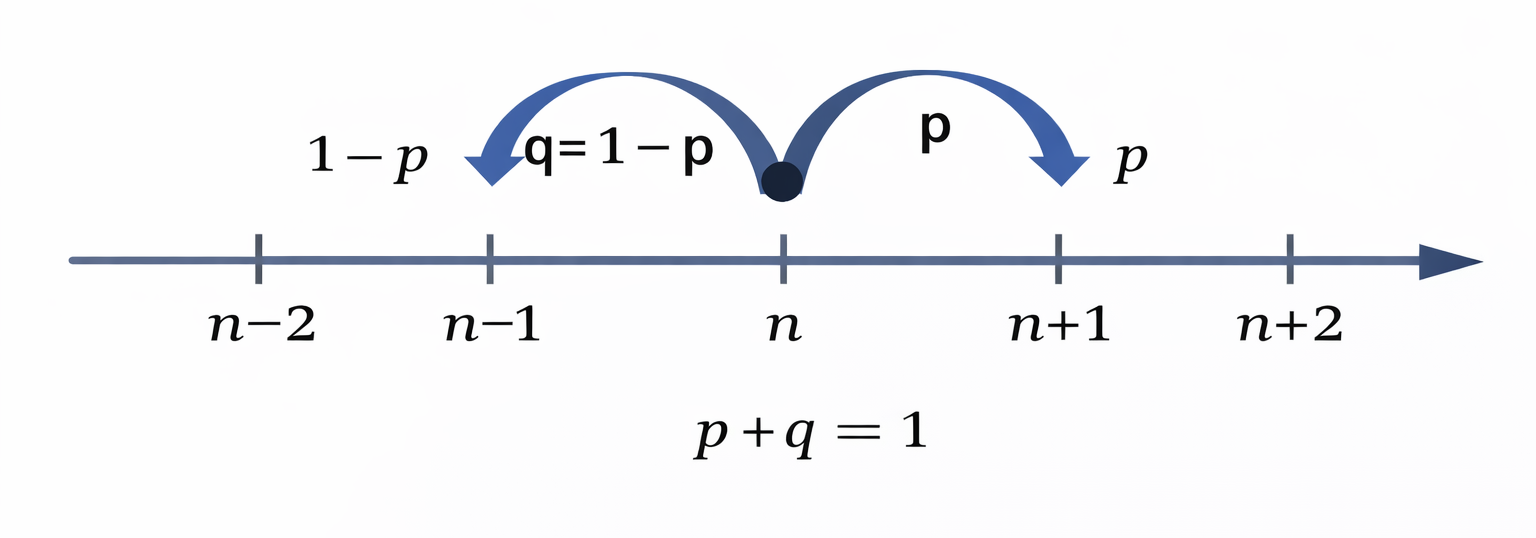

Consideremos ahora el caso particular de una caminata aleatoria
unidimensional, en la cual el caminante se desplaza una unidad
hacia la derecha con probabilidad $p$ y una unidad hacia la izquierda
con probabilidad $q$, cumpliéndose que

$$
p + q = 1.
$$

---

*Código*

---

Declaramos las librerias a usar:

In [ ]:
import random as rd
import matplotlib.pyplot as plt
import numpy as np

Comienza un ciclo externo que se repite tantas veces como caminatas se desean simular. Cada repetición representa una caminata completamente nueva e independiente de las demás. En cada caminata, la variable posicion se inicializa en cero, lo cual corresponde a la condición inicial $X_0 = 0$.

Dentro de cada caminata, se ejecuta un segundo ciclo que recorre los n pasos. En cada paso se genera un número aleatorio uniforme entre 0 y 1. Este número se compara con p. Si el número es menor que p, la posición aumenta en uno (movimiento hacia la derecha). En caso contrario, disminuye en uno (movimiento hacia la izquierda). Este procedimiento reproduce exactamente la definición probabilística del incremento $S_𝑘$.

**Simula una caminata aleatoria 1D.**

Parámetros
* p : Probabilidad de moverse a la derecha.
* n_pasos : Número de pasos por caminata.
* n_caminatas_estadistica : Número de caminatas independientes.

Retorna
* valores_finales: Vector con la posición final de cada caminata.


In [ ]:
p = 0.5
n_pasos = 500

In [ ]:
def caminata(p, n_pasos):

    trayectoria = np.zeros(n_pasos + 1)  # Incluye X0
    posicion = 0

    for n in range(1, n_pasos + 1):
        r = np.random.rand()

        if r < p:
            posicion += 1
        else:
            posicion -= 1

        trayectoria[n] = posicion

    return trayectoria

In [ ]:
valores = caminata(p, n_pasos)

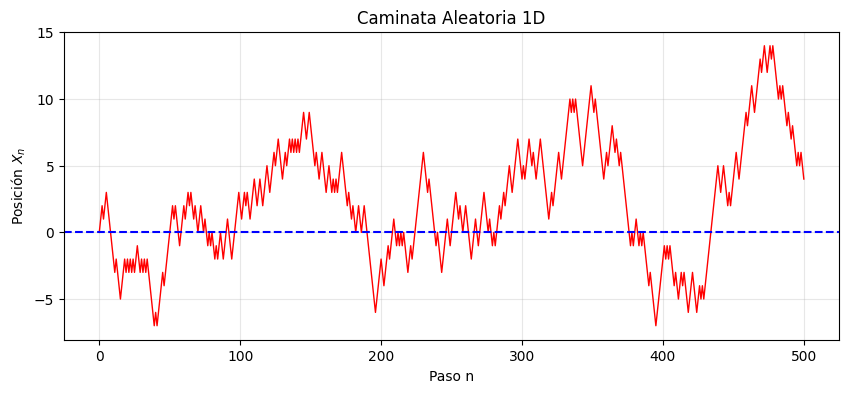

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(valores, color='red', linewidth=1)
plt.axhline(0, color='blue', linestyle='--')
plt.title("Caminata Aleatoria 1D")
plt.xlabel("Paso n")
plt.ylabel("Posición $X_n$")
plt.grid(alpha=0.3)
plt.show()

---

*Ahora vamos a elegir el número de pasos que  queremos para nuestra simulación.*

### **¿Dónde terminará la partícula si p = 0.5?**


Se crea una lista vacía llamada fin. Su único objetivo es guardar el número de la casilla donde terminó cada una de las 1,000 caminatas (ciclo donde se harán 1000 iteraciones).

El índice $[-1]$ tomará el último elemento de la lista yaya que no  me interesa saber qué pasó en antes, solo quiero saber en qué posición quedó la partícula al final del paso 200.

Finalmente calculamos el promedio de las distancias.

In [ ]:
fin = []
for i in range(1000):
    recorrido = caminata(p, 200) # Hacemos 200 pasos
    posicion_final = recorrido[-1]             # Tomamos el último dato
    fin.append(posicion_final)

promedio = sum(fin) / len(fin)
print(f"El promedio de los finales de 1000 caminatas es: {promedio}")

El promedio de los finales de 1000 caminatas es: -0.372


### **¿A qué distancia del origen suele estar la partícula?**


Se crea una lista vacía llamada **dist_abs**. Su único objetivo es guardar el número de la casilla donde terminó cada una de las 1,000 caminatas (ciclo donde se harán 1000 iteraciones).

El índice $[-1]$ tomará el último elemento de la lista ya que no  me interesa saber qué pasó en antes, solo quiero saber en qué posición quedó la partícula al final del paso 400.

Finalmente calculamos el promedio de las distancias.

In [ ]:
dist_abs = []

for i in range(1000):
    recorrido = caminata(p, 400)  # n = 400
    posicion_final = recorrido[-1]

    dist_abs.append(abs(posicion_final))    # Usamos abs() para tomar la distincia (d>0)

promedio_distancia = sum(dist_abs) / len(dist_abs)

print(f"Distancia promedio después de 400 pasos: {promedio_distancia}")
print(f"Raíz cuadrada de 400 es: {400**0.5}")

Distancia promedio después de 400 pasos: 16.026
Raíz cuadrada de 400 es: 20.0


Aunque el promedio de la posición se mantiene cercano a **cero**, esto no implica que la partícula permanezca próxima al origen. En realidad, la magnitud típica de su desplazamiento aumenta con el número de pasos, pero no de manera proporcional al tiempo. La separación respecto al punto inicial crece más lentamente, siguiendo una dependencia proporcional a la raíz cuadrada del número de pasos, en lugar de crecer linealmente.

---

**Análisis**

---

En la simulación de la caminata aleatoria unidimensional con $p=0.5$ (y por lo tanto $q=0.5$), el proceso es simétrico, es decir, no existe una preferencia sistemática por desplazarse hacia la derecha o hacia la izquierda. Matemáticamente, el proceso se define como

$$
X_0 = 0
$$

y para $n \geq 1$,

$$
X_n = \sum_{k=1}^{n} S_k,
$$

donde cada incremento $S_k$ satisface

$$
S_k =
\begin{cases}
+1 & \text{con probabilidad } p, \\
-1 & \text{con probabilidad } q,
\end{cases}
$$

con $p+q=1$.

En el caso particular $p=0.5$, se tiene

$$
\mathbb{E}[S_k] = p - q = 0,
$$

por lo que

$$
\mathbb{E}[X_n] = n \mathbb{E}[S_k] = 0.
$$

Esto explica por qué el promedio empírico de las posiciones finales, obtenido mediante simulación, es cercano a cero. La pequeña desviación observada (por ejemplo, $-0.372$ en 1 000 simulaciones) se debe únicamente a fluctuaciones aleatorias propias del tamaño finito de la muestra.

Sin embargo, que el promedio de $X_n$ sea aproximadamente cero no implica que la partícula permanezca cerca del origen. Para analizar el alejamiento típico, es más adecuado estudiar la distancia absoluta $|X_n|$. En la simulación realizada para $n=400$, se obtuvo una distancia promedio cercana a $16$, lo cual indica que la partícula suele encontrarse relativamente lejos del origen tras muchos pasos.

Teóricamente, la varianza del proceso está dada por

$$
\mathrm{Var}(X_n) = n \cdot 4p(1-p).
$$

Para $p=0.5$, esto se reduce a

$$
\mathrm{Var}(X_n) = n.
$$

Por lo tanto, la desviación estándar es

$$
\sqrt{\mathrm{Var}(X_n)} = \sqrt{n}.
$$

Esto muestra que la escala típica del desplazamiento crece proporcionalmente a $\sqrt{n}$, y no de manera lineal con $n$. Así, aunque el promedio de la posición se mantenga cercano a cero, la magnitud del desplazamiento aumenta conforme crece el número de pasos.



---

 **Conclusiones**

---
La caminata aleatoria 1D con $p=0.5$ es un proceso estocástico simétrico cuya esperanza cumple

$$
\mathbb{E}[X_n] = 0,
$$

lo que implica ausencia de deriva sistemática. No obstante, la dispersión del proceso aumenta con el tiempo.

La simulación confirma que, aunque la posición promedio permanece cercana al origen, la distancia típica al mismo crece aproximadamente como

$$
|X_n| \sim \sqrt{n}.
$$

Este comportamiento refleja una dinámica difusiva: el sistema no evoluciona linealmente en el tiempo, sino que su alejamiento característico aumenta más lentamente, gobernado por la raíz cuadrada del número de pasos.

En consecuencia, la caminata aleatoria constituye un modelo fundamental para describir fenómenos de difusión y fluctuaciones acumulativas, donde la ausencia de tendencia media no impide un crecimiento progresivo de la variabilidad.
